In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

import torchvision
from torchvision import models, transforms

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [3]:
ROOT_DIR = 'fairface_dataset'
TRAIN_CSV = os.path.join(ROOT_DIR, 'fairface-label-train.csv')
VAL_CSV = os.path.join(ROOT_DIR, 'fairface-label-val.csv')

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

train_df.head()

,file,age,gender,race,service_test
0,train/1.jpg,59,Male,East Asian,True
1,train/2.jpg,39,Female,Indian,False
2,train/3.jpg,11,Female,Black,False
3,train/4.jpg,26,Female,Indian,True
4,train/5.jpg,26,Female,Indian,True


In [4]:
GENDER_TO_LABEL = {'Male': 0, 'Female': 1}

class FairFaceGenderDataset(Dataset):
    def __init__(self, csv_path, root_dir, image_size=224):
        self.df = pd.read_csv(csv_path)
        self.root_dir = root_dir
        self.image_size = image_size
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                               std=[0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, ix):
        row = self.df.iloc[ix]
        img_path = os.path.join(self.root_dir, row['file'])
        im = cv2.imread(img_path)[:, :, ::-1]
        im = cv2.resize(im, (self.image_size, self.image_size))
        im = torch.tensor(im / 255)
        im = im.permute(2, 0, 1)
        im = self.normalize(im)

        label = GENDER_TO_LABEL[row['gender']]

        return (
            im.float().to(device),
            torch.tensor([label]).float().to(device)
        )

In [5]:
train_dataset = FairFaceGenderDataset(TRAIN_CSV, ROOT_DIR)
valid_dataset = FairFaceGenderDataset(VAL_CSV, ROOT_DIR)

len(train_dataset), len(valid_dataset)

(86744, 10954)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.21734205].


tensor([0.], device='cuda:0')


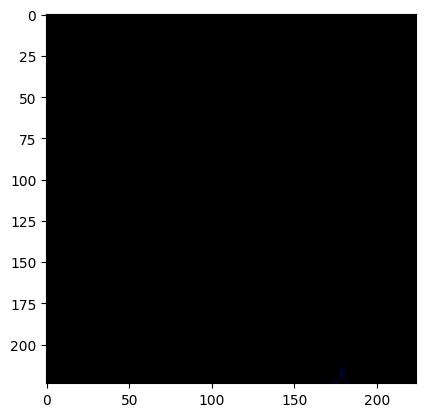

In [6]:
im, label = train_dataset[0]
plt.imshow(im.permute(1, 2, 0).cpu())
print(label)

In [7]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

In [8]:
def get_model():
    model = models.resnet18(pretrained=True).to(device)

    for param in model.parameters():
        param.requires_grad = False

    model.avgpool = nn.AdaptiveAvgPool2d(output_size=(1, 1))
    model.fc = nn.Sequential(
        nn.Flatten(),
        nn.Linear(512, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 1),
        nn.Sigmoid()
    )

    loss_fn = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    return model.to(device), loss_fn, optimizer

In [9]:
def accuracy(outputs, targets):
    prediction = outputs
    is_correct = (prediction > 0.5) == targets
    return is_correct.cpu().numpy().sum() / targets.size(0)


def train(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    for inputs, targets in dataloader:
        optimizer.zero_grad()
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_acc += accuracy(outputs, targets)
    return total_loss / len(dataloader), total_acc / len(dataloader)


def validate(model, dataloader, criterion):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item()
            total_acc += accuracy(outputs, targets)
    return total_loss / len(dataloader), total_acc / len(dataloader)

Epoch 1/15, Train Loss: 0.5393, Validation Loss: 0.5121, Train Accuracy: 0.7196, Validation Accuracy: 0.7297
Epoch 2/15, Train Loss: 0.5146, Validation Loss: 0.4922, Train Accuracy: 0.7361, Validation Accuracy: 0.7495
Epoch 3/15, Train Loss: 0.5033, Validation Loss: 0.4908, Train Accuracy: 0.7434, Validation Accuracy: 0.7485
Epoch 4/15, Train Loss: 0.4952, Validation Loss: 0.4844, Train Accuracy: 0.7504, Validation Accuracy: 0.7534
Epoch 5/15, Train Loss: 0.4901, Validation Loss: 0.4842, Train Accuracy: 0.7526, Validation Accuracy: 0.7569
Epoch 6/15, Train Loss: 0.4843, Validation Loss: 0.4804, Train Accuracy: 0.7580, Validation Accuracy: 0.7577
Epoch 7/15, Train Loss: 0.4803, Validation Loss: 0.4785, Train Accuracy: 0.7612, Validation Accuracy: 0.7581
Epoch 8/15, Train Loss: 0.4766, Validation Loss: 0.4794, Train Accuracy: 0.7622, Validation Accuracy: 0.7582
Epoch 9/15, Train Loss: 0.4744, Validation Loss: 0.4741, Train Accuracy: 0.7645, Validation Accuracy: 0.7583
Epoch 10/15, Train 

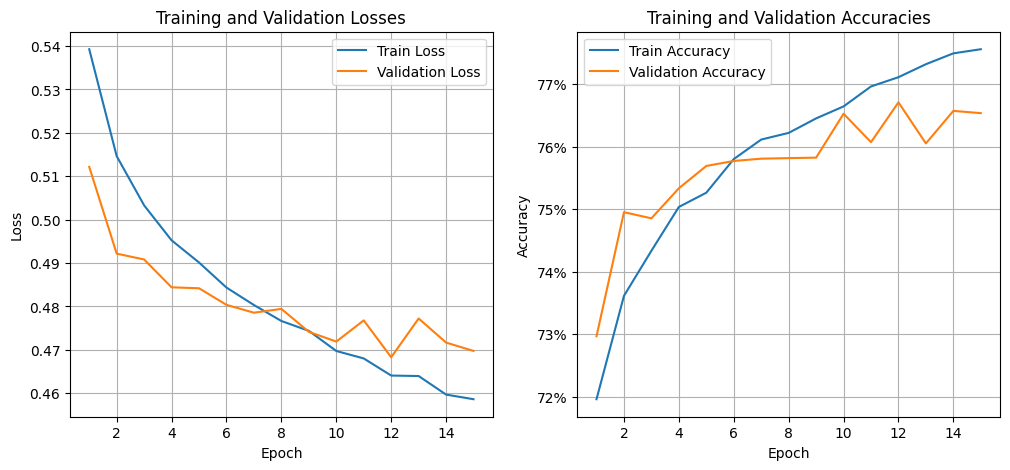

In [11]:
model, loss_fn, optimizer = get_model()

n_epochs = 15
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(n_epochs):
    train_loss, train_acc = train(model, train_dataloader, optimizer, loss_fn)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_loss, val_acc = validate(model, valid_dataloader, loss_fn)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}, "
          f"Train Accuracy: {train_acc:.4f}, Validation Accuracy: {val_acc:.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, n_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies, label='Train Accuracy')
plt.plot(range(1, n_epochs + 1), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracies')
plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid(True)

plt.show()